In [3]:
import pandas as pd

dataframes = []


df = pd.read_csv("analysed_dataframe/NVDA_2014-2023.csv")
dataframes.append(df)


combined_df = pd.concat(dataframes, ignore_index=True)

combined_df = combined_df.sort_values(by="time")

In [4]:
from dataAnalyser import *
from utility import *
from model import *
from datetime import datetime
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, Subset 
import torch
import numpy as np
import time


In [5]:
datas = []
targets = []
for i in range(len(combined_df) - 1):
    current_row = combined_df.iloc[i]
    next_row = combined_df.iloc[i + 1]
    input_data = torch.tensor([current_row["openPrice"],current_row["closePrice"],current_row["highPrice"],current_row["lowPrice"],current_row["sma"],current_row["ema"],current_row["rsi"],current_row["volume"]])
    target = torch.tensor([next_row["closePrice"],next_row["highPrice"], next_row["lowPrice"]])
    datas.append(input_data)
    targets.append(target)
print(len(datas))

35707


In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

data = torch.tensor(np.array(datas))
target = torch.tensor(np.array(targets))
to_normalize_data = data[:,:7] #take the first 6 columns
to_normalize_volume = data[:,6].reshape(-1, 1) #take the volume column

scaler_volume = MinMaxScaler()
scaler_input_data = MinMaxScaler()
scaler_target_dim_3 = MinMaxScaler()

normalized_data = torch.tensor(scaler_input_data.fit_transform(to_normalize_data))
normalized_volume = torch.tensor(scaler_volume.fit_transform(to_normalize_volume))

normalized_input = torch.cat((normalized_data, normalized_volume),1)
normalized_target = torch.tensor(scaler_target_dim_3.fit_transform(target))

In [7]:
dataset = LSTM_Dataset(inputs=normalized_input, labels=normalized_target,time_series_len=32)

training_index = int(len(dataset)*0.7)
validating_index = int(len(dataset)*0.15)

def generate_indices(start,end):
  indices = []
  for i in range(start, end):
    indices.append(i)
  return indices

training_indices = generate_indices(0,training_index)
validating_indices = generate_indices(training_index,training_index+validating_index)
testing_indices = generate_indices(training_index+validating_index,len(dataset))
training_set = Subset(dataset,training_indices)
validation_set = Subset(dataset,validating_indices)
testing_set = Subset(dataset,testing_indices)

training_loader = torch.utils.data.DataLoader(training_set, batch_size=1, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=1, shuffle=False)
testing_loader = torch.utils.data.DataLoader(testing_set, batch_size=1, shuffle=False)

torch.Size([35675, 32, 8])
torch.Size([35675, 3])


In [8]:
device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )

print(f"Using {device} device")

model = TradingModel(8,600,0.2).to(device)
nom = input("name of the file\n")
model.load_state_dict(torch.load("model/"+nom, map_location=device))
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')

test_loss =0.0
val_loss = 0.0

Using cpu device


²

In [28]:
def train_one_epoch(set_loader,train=False):
  running_loss = 0.0
  predicted = []
  target = []
  for i, data in enumerate(set_loader):
        optimizer.zero_grad()

        inputs, labels = data


        inputs = inputs.to(torch.float32)
        labels = labels.to(torch.float32)


        inputs = inputs.to(device)
        labels = labels.to(device)
        output = model(inputs)
        
        
        loss = loss_fn(output, labels)
        running_loss +=loss.item()
        if train :
          loss.backward()
          optimizer.step()
          scheduler.step(running_loss)
        else:
          predicted.append(output[-1].cpu().detach())
          target.append(labels[-1].cpu().detach())

          if i >= 2900:
            #predicted_denormalized = scaler_target_dim_3.inverse_transform(torch.tensor(np.array(predicted)))
            #input_denormalized = scaler_input_data.inverse_transform(torch.tensor(np.array(inputs[0][:,:7])))
            #target_denormalized = scaler_target_dim_3.inverse_transform((torch.tensor(np.array(target))))
            
            predicted_denormalized = torch.tensor(np.array(predicted))
            target_denormalized = torch.tensor(np.array(target))
            input_denormalized = torch.tensor(np.array(inputs))
            
            time = np.arange(0, len(predicted))
            print(predicted_denormalized[:,0].shape)
            plt.clf()
            plt.plot(time,predicted_denormalized[:,0],'-', color='blue')
            plt.plot(time,target_denormalized[:,0],'-', color='red')
            plt.show(block=False)
            print("predicted",predicted_denormalized[-1])
            print("target",target_denormalized[-1])
            print("input",input_denormalized[0][-1][1])
            input("continue")
  return predicted, target

torch.Size([2901])


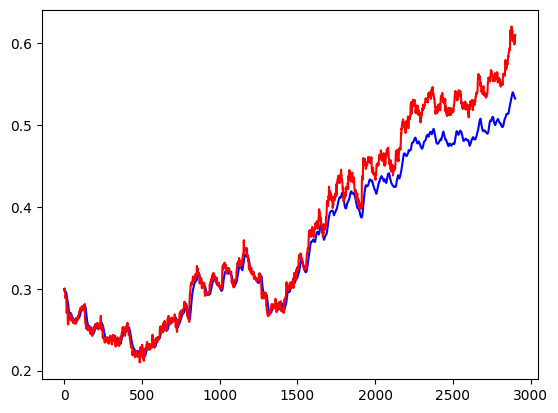

predicted tensor([0.2999, 0.2598, 0.3020])
target tensor([0.2981, 0.2577, 0.3006])
input tensor(0.6038)


In [29]:
model.train(False)
predicted, target = train_one_epoch(testing_loader, False)